In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
data = {
    "Province": ["Punjab", "Sindh", "Khyber Pakhtunkhwa", "Balochistan"],
    "Population (millions)": [110, 50, 30, np.nan],
    "Literacy Rate (%)": [64, np.nan, 55, 43],
    "Region": ["East", "South", "North", "West"]
}

df = pd.DataFrame(data)

print(df)

             Province  Population (millions)  Literacy Rate (%) Region
0              Punjab                  110.0               64.0   East
1               Sindh                   50.0                NaN  South
2  Khyber Pakhtunkhwa                   30.0               55.0  North
3         Balochistan                    NaN               43.0   West


In [3]:
data = {
    "Province": ["Punjab", "Sindh", "Khyber Pakhtunkhwa", "Balochistan"],
    "Population (millions)": [110, 50, 30, np.nan],
    "Literacy Rate (%)": [64, np.nan, 55, 43],
    "Region": ["East", "South", "North", "West"]
}

df = pd.DataFrame(data)

print(df)

             Province  Population (millions)  Literacy Rate (%) Region
0              Punjab                  110.0               64.0   East
1               Sindh                   50.0                NaN  South
2  Khyber Pakhtunkhwa                   30.0               55.0  North
3         Balochistan                    NaN               43.0   West


In [4]:
print(df.isnull().sum())

Province                 0
Population (millions)    1
Literacy Rate (%)        1
Region                   0
dtype: int64


In [6]:
df = df.dropna(subset=["Population (millions)"])
print(df)

             Province  Population (millions)  Literacy Rate (%) Region
0              Punjab                  110.0               64.0   East
1               Sindh                   50.0                NaN  South
2  Khyber Pakhtunkhwa                   30.0               55.0  North


In [14]:
# median_Literacy = df["Literacy rate (%)"].median()
median_literacy = df["Literacy Rate (%)"].median()
df["Literacy Rate (%)"]=df["Literacy Rate (%)"].fillna(median_literacy)

print(df)

             Province  Population (millions)  Literacy Rate (%) Region
0              Punjab                  110.0               64.0   East
1               Sindh                   50.0               59.5  South
2  Khyber Pakhtunkhwa                   30.0               55.0  North


In [15]:
label_encoder = LabelEncoder()

df["Region_Label"] = label_encoder.fit_transform(df["Region"])

print(df)

             Province  Population (millions)  Literacy Rate (%) Region  \
0              Punjab                  110.0               64.0   East   
1               Sindh                   50.0               59.5  South   
2  Khyber Pakhtunkhwa                   30.0               55.0  North   

   Region_Label  
0             0  
1             2  
2             1  


In [16]:
one_hot = pd.get_dummies(df["Region"], prefix="Region")

print(one_hot)

   Region_East  Region_North  Region_South
0         True         False         False
1        False         False          True
2        False          True         False


In [17]:
df = pd.concat([df, one_hot], axis=1)

print(df)

             Province  Population (millions)  Literacy Rate (%) Region  \
0              Punjab                  110.0               64.0   East   
1               Sindh                   50.0               59.5  South   
2  Khyber Pakhtunkhwa                   30.0               55.0  North   

   Region_Label  Region_East  Region_North  Region_South  
0             0         True         False         False  
1             2        False         False          True  
2             1        False          True         False  


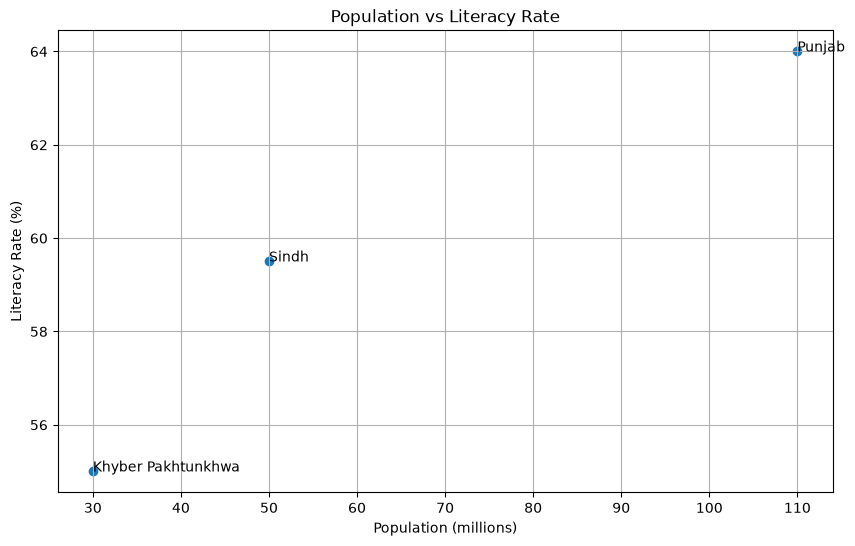

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Population (millions)"],
    df["Literacy Rate (%)"]
)

for i in range(len(df)):
    plt.annotate(
        df["Province"].iloc[i],
        (
            df["Population (millions)"].iloc[i],
            df["Literacy Rate (%)"].iloc[i]
        )
    )

plt.xlabel("Population (millions)")
plt.ylabel("Literacy Rate (%)")
plt.title("Population vs Literacy Rate")
plt.grid(True)

plt.show()

In [19]:
Q1 = df["Literacy Rate (%)"].quantile(0.25)
Q3 = df["Literacy Rate (%)"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 57.25
Q3: 61.75


In [21]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 4.5


In [22]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 50.5
Upper Bound: 68.5


In [23]:
outliers = df[
    (df["Literacy Rate (%)"] < lower_bound) |
    (df["Literacy Rate (%)"] > upper_bound)
]

print("Outliers:")
print(outliers[["Province", "Literacy Rate (%)"]])

Outliers:
Empty DataFrame
Columns: [Province, Literacy Rate (%)]
Index: []
